# TIFF Folder to Stack

Combine a folder of individual TIFF slices (e.g. XCT reconstruction output) into a single multi-page (Big)TIFF stack.

**Requirements:** `pip install tifffile numpy natsort`

Notes:
- Uses BigTIFF automatically so 2000+ slice CT stacks aren't limited by the classic 4GB TIFF cap.
- Writes slice-by-slice instead of loading the whole volume into RAM first.
- Slices are sorted "naturally" (`slice_2.tif` before `slice_10.tif`) rather than alphabetically.
- Validates that every slice matches the first slice's shape/dtype before writing.


In [6]:
import sys
from pathlib import Path

import numpy as np
import tifffile
from natsort import natsorted

## 1. Set your paths

Edit these two variables, then run the rest of the notebook top to bottom.

In [ ]:
# --- EDIT THESE ---
INPUT_FOLDER = Path("/path/to/folder")
OUTPUT_FILE = Path("/path/to/file.tif")
DRY_RUN = True  # set to False once you've checked the ordering below
# -------------------

## 2. Helper functions

In [8]:
def find_tiffs(folder: Path):
    exts = (".tif", ".tiff")
    files = [f for f in folder.iterdir() if f.suffix.lower() in exts]
    if not files:
        raise FileNotFoundError(f"No .tif/.tiff files found in {folder}")
    return natsorted(files, key=lambda p: p.name)


def build_stack(folder: Path, output_path: Path, dry_run: bool = False):
    files = find_tiffs(folder)
    print(f"Found {len(files)} TIFF files in {folder}")

    # Inspect first file to get shape/dtype and confirm the rest match
    first = tifffile.imread(files[0])
    shape = first.shape
    dtype = first.dtype
    print(f"Reference slice: {files[0].name}  shape={shape}  dtype={dtype}")

    if dry_run:
        print("Dry run only - listing first/last 5 files in stitch order:")
        for f in files[:5]:
            print(f"  {f.name}")
        print("  ...")
        for f in files[-5:]:
            print(f"  {f.name}")
        return

    output_path.parent.mkdir(parents=True, exist_ok=True)

    with tifffile.TiffWriter(output_path, bigtiff=True) as writer:
        for i, f in enumerate(files):
            img = tifffile.imread(f)

            if img.shape != shape:
                raise ValueError(
                    f"Shape mismatch at slice {i} ({f.name}): "
                    f"expected {shape}, got {img.shape}"
                )
            if img.dtype != dtype:
                raise ValueError(
                    f"Dtype mismatch at slice {i} ({f.name}): "
                    f"expected {dtype}, got {img.dtype}"
                )

            writer.write(img, contiguous=True)

            if (i + 1) % 200 == 0 or (i + 1) == len(files):
                print(f"  wrote {i + 1}/{len(files)} slices")

    print(f"Done. Stack written to {output_path}")
    print(f"Final volume shape: ({len(files)}, {shape[0]}, {shape[1]})  dtype={dtype}")

## 3. Dry run

Check that the slice ordering looks right *before* writing a large stack. Confirm the naming sorts correctly (e.g. `slice_0001.tif` vs `slice_1.tif` can sort very differently depending on padding).

In [9]:
build_stack(INPUT_FOLDER, OUTPUT_FILE, dry_run=True)

Found 2028 TIFF files in /home/charlie/usb_drive/2. 09-03-26/CB_090326_RUN2_01
Reference slice: CB_090326_RUN2_01_0001.tif  shape=(812, 698)  dtype=uint16
Dry run only - listing first/last 5 files in stitch order:
  CB_090326_RUN2_01_0001.tif
  CB_090326_RUN2_01_0002.tif
  CB_090326_RUN2_01_0003.tif
  CB_090326_RUN2_01_0004.tif
  CB_090326_RUN2_01_0005.tif
  ...
  CB_090326_RUN2_01_2024.tif
  CB_090326_RUN2_01_2025.tif
  CB_090326_RUN2_01_2026.tif
  CB_090326_RUN2_01_2027.tif
  CB_090326_RUN2_01_2028.tif


## 4. Build the stack

Once the ordering above looks correct, run this cell to actually write the stack.

In [10]:
build_stack(INPUT_FOLDER, OUTPUT_FILE, dry_run=False)

Found 2028 TIFF files in /home/charlie/usb_drive/2. 09-03-26/CB_090326_RUN2_01
Reference slice: CB_090326_RUN2_01_0001.tif  shape=(812, 698)  dtype=uint16
  wrote 200/2028 slices
  wrote 400/2028 slices
  wrote 600/2028 slices
  wrote 800/2028 slices
  wrote 1000/2028 slices
  wrote 1200/2028 slices
  wrote 1400/2028 slices
  wrote 1600/2028 slices
  wrote 1800/2028 slices
  wrote 2000/2028 slices
  wrote 2028/2028 slices
Done. Stack written to /home/charlie/usb_drive/Charlie/data/Stitched/1_stitch_stitched.tif
Final volume shape: (2028, 812, 698)  dtype=uint16


## 5. (Optional) Quick sanity check

Load the resulting stack and view the middle slice to confirm it wrote correctly.

Stack shape: (2028, 2028, 2028) dtype: uint16


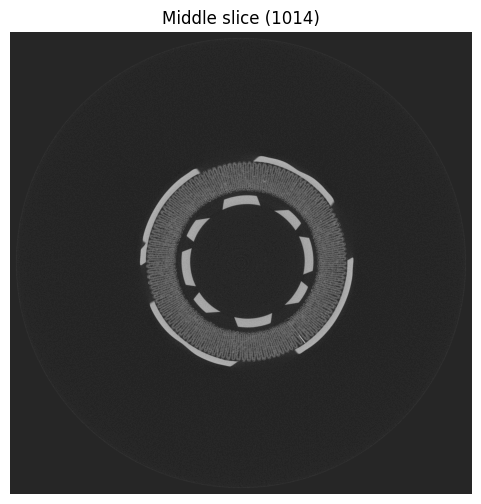

In [15]:
import matplotlib.pyplot as plt

stack = tifffile.imread(OUTPUT_FILE)
print("Stack shape:", stack.shape, "dtype:", stack.dtype)

mid = stack.shape[0] // 2
plt.figure(figsize=(6, 6))
plt.imshow(stack[mid], cmap="gray")
plt.title(f"Middle slice ({mid})")
plt.axis("off")
plt.show()

In [9]:
from pathlib import Path
import tifffile
from natsort import natsorted

folder = Path("/home/charlie/CB_090326_RUN2_01/")  # same INPUT_FOLDER you used before
files = natsorted([f for f in folder.iterdir() if f.suffix.lower() in (".tif", ".tiff")], key=lambda p: p.name)

print(f"Total files found: {len(files)}")
print("\nFirst 5 files in sort order:")
for f in files[:5]:
    print(f" ", f.name)

print("\nShape check across a spread of files:")
for idx in [0, 1, 2, 10, 100, 1000, len(files) - 1]:
    img = tifffile.imread(files[idx])
    print(f"  index {idx:>5} ({files[idx].name}): shape={img.shape} dtype={img.dtype}")

Total files found: 2028

First 5 files in sort order:
  CB_090326_RUN2_01_0001.tif
  CB_090326_RUN2_01_0002.tif
  CB_090326_RUN2_01_0003.tif
  CB_090326_RUN2_01_0004.tif
  CB_090326_RUN2_01_0005.tif

Shape check across a spread of files:
  index     0 (CB_090326_RUN2_01_0001.tif): shape=(812, 698) dtype=uint16
  index     1 (CB_090326_RUN2_01_0002.tif): shape=(812, 698) dtype=uint16
  index     2 (CB_090326_RUN2_01_0003.tif): shape=(812, 698) dtype=uint16
  index    10 (CB_090326_RUN2_01_0011.tif): shape=(812, 698) dtype=uint16
  index   100 (CB_090326_RUN2_01_0101.tif): shape=(812, 698) dtype=uint16
  index  1000 (CB_090326_RUN2_01_1001.tif): shape=(812, 698) dtype=uint16
  index  2027 (CB_090326_RUN2_01_2028.tif): shape=(812, 698) dtype=uint16


## 6. Repeat for each scan

Run this notebook once per scan (e.g. three times for three scans), changing `INPUT_FOLDER` and `OUTPUT_FILE` in step 1 each time.